In [68]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "scikit-learn"])


0

In [69]:
import math
import pandas as pd
import numpy as np
from operator import itemgetter


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics


from sklearn import tree
from sklearn.tree import _tree

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression


from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

In [70]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
INFILE = "C:\\Users\\dchee\\OneDrive\\Documents\\Grad School\\MSDS 422 - Machine Learning\\Module 1\\hmeq_assignment_1.csv"

df = pd.read_csv(INFILE)

In [71]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
TARGET_BAD_FLAG,5960.0,0.199497,0.399656,0.000000,0.000000,0.000000,0.000000,1.000000
TARGET_LOSS_AMT,1189.0,13414.576955,10839.455965,224.000000,5639.000000,11003.000000,17634.000000,78987.000000
LOAN,5960.0,18607.969799,11207.480417,1100.000000,11100.000000,16300.000000,23300.000000,89900.000000
z_IMP_JOB_MISSING,5960.0,0.046812,0.211254,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_Mgr,5960.0,0.128691,0.334886,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_Office,5960.0,0.159060,0.365763,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_Other,5960.0,0.400671,0.490076,0.000000,0.000000,0.000000,1.000000,1.000000
z_IMP_JOB_Sales,5960.0,0.018289,0.134004,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_ProfExe,5960.0,0.214094,0.410227,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_Self,5960.0,0.032383,0.177029,0.000000,0.000000,0.000000,0.000000,1.000000


In [72]:
## Find the variables that are objects, integers, and floats. Put them in a list.

# print(df.dtypes)
dt = df.dtypes
print(dt)
# print(df.describe().T)

objList = []
intList = []
floatList = []


TARGET_F = "TARGET_BAD_FLAG"
TARGET_A = "TARGET_LOSS_AMT"

for i in dt.index:
    # print(" here is i ....", i, ".... and here is the type", dt[i])
    if i in ( [TARGET_F, TARGET_A] ): continue
    if dt[i] in (["object"]) : objList.append(i)
    if dt[i] in (["float64"]) : floatList.append(i)
    if dt[i] in (["int64"]) : intList.append(i)

# print(" OBJECTS ")
# print('  ------ ')
# for i in objList:
#     print(i)
# print(" INTEGERS ")
# print('  ------ '\n)
# for i in intList:
#     print(i)
# print(" FLOAT ")
# print('  ------ ')
# for i in floatList:
#     print(i)


### Explore the Categorical / Object Variables
# for i in objList:
#         print(" Class = ", i)
#         g = df.groupby(i)
#         # print(g[i].count())
#         x = g[TARGET_F].mean()
#         print('Loan Owed = ', x)
#         print(" ---------- ")
#         x = g[TARGET_A].mean()
#         print('Remaining  Amount = ', x)
#         print(' =============\n\n\n')




TARGET_BAD_FLAG           int64
TARGET_LOSS_AMT         float64
LOAN                      int64
z_IMP_JOB_MISSING         int64
z_IMP_JOB_Mgr             int64
z_IMP_JOB_Office          int64
z_IMP_JOB_Other           int64
z_IMP_JOB_Sales           int64
z_IMP_JOB_ProfExe         int64
z_IMP_JOB_Self            int64
z_IMP_REASON_MISSING      int64
z_IMP_REASON_HomeImp      int64
z_IMP_REASON_DebtCon      int64
M_MORTDUE                 int64
IMP_MORTDUE             float64
M_VALUE                   int64
IMP_VALUE               float64
M_YOJ                     int64
IMP_YOJ                 float64
M_DEROG                   int64
IMP_DEROG               float64
M_DELINQ                  int64
IMP_DELINQ              float64
M_CLAGE                   int64
IMP_CLAGE               float64
M_NINQ                    int64
IMP_NINQ                float64
M_CLNO                    int64
IMP_CLNO                float64
M_DEBTINC                 int64
IMP_DEBTINC             float64
dtype: o

In [73]:
X = df.drop(columns=[TARGET_F, TARGET_A])
Y = df[[TARGET_F, TARGET_A]]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=1
)

# Subset to loans that defaulted (TARGET_LOSS_AMT not null)
F_train = ~Y_train[TARGET_A].isna()
F_test  = ~Y_test[TARGET_A].isna()

W_train = X_train.loc[F_train].copy()
Z_train = Y_train.loc[F_train, TARGET_A].copy()
W_test  = X_test.loc[F_test].copy()
Z_test  = Y_test.loc[F_test, TARGET_A].copy()

# 2. Linear Regression model
linreg = LinearRegression()
linreg.fit(W_train, Z_train)

# Predictions
pred_train = linreg.predict(W_train)
pred_test  = linreg.predict(W_test)

# 3. RMSE metrics
rmse_train = np.sqrt(metrics.mean_squared_error(Z_train, pred_train))
rmse_test  = np.sqrt(metrics.mean_squared_error(Z_test, pred_test))

print("### Linear Regression (All Variables) Results ###\n")
print("Intercept:", linreg.intercept_)
print("Train RMSE:", round(rmse_train, 2))
print("Test RMSE:", round(rmse_test, 2))
print("\nCoefficients:\n")
for name, coef in zip(W_train.columns, linreg.coef_):
    print(f"{name} = {coef}")

# 4. Interpretation summary
print("\n--- Summary ---")
print(f"The model's Test RMSE ({rmse_test:,.2f}) means average prediction error is roughly ${rmse_test:,.0f}.")
print("If this is smaller than other models' RMSEs (e.g., tree-based), linear regression is more accurate.")

### Linear Regression (All Variables) Results ###

Intercept: -9191.044755272567
Train RMSE: 3613.47
Test RMSE: 3493.14

Coefficients:

LOAN = 0.7593493336315721
z_IMP_JOB_MISSING = 954.5916779330838
z_IMP_JOB_Mgr = -733.4895449809146
z_IMP_JOB_Office = -507.47495838158113
z_IMP_JOB_Other = -417.87721622837444
z_IMP_JOB_Sales = 785.4546679905667
z_IMP_JOB_ProfExe = -917.9573930574469
z_IMP_JOB_Self = 836.7527600341601
z_IMP_REASON_MISSING = -787.6020444189138
z_IMP_REASON_HomeImp = -568.7781299477804
z_IMP_REASON_DebtCon = 1356.3801743667527
M_MORTDUE = -630.3290566695449
IMP_MORTDUE = 0.006818437769118121
M_VALUE = 84.82079676951777
IMP_VALUE = -0.0047390677661427625
M_YOJ = -17.06300035414481
IMP_YOJ = -87.19176941479859
M_DEROG = 797.9397669264193
IMP_DEROG = 318.578634867233
M_DELINQ = 332.2852404137051
IMP_DELINQ = 733.6384007197188
M_CLAGE = -5543.799635261365
IMP_CLAGE = -18.66493863187074
M_NINQ = -1116.8487119578551
IMP_NINQ = -65.04723643838652
M_CLNO = 7512.9047636653395
IMP

In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
import numpy as np
import pandas as pd

print("### Linear Regression – ALL VARIABLES (Loss given Default)")

# Use only loans that defaulted and have a loss amount
df_defaulted = df[(df["TARGET_BAD_FLAG"] == 1) & df["TARGET_LOSS_AMT"].notna()].copy()

X = df_defaulted.drop(columns=["TARGET_LOSS_AMT"])
y = df_defaulted["TARGET_LOSS_AMT"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=1
)

lin_all = LinearRegression()
lin_all.fit(X_train, y_train)

# Predictions
y_pred_train = lin_all.predict(X_train)
y_pred_test  = lin_all.predict(X_test)

# RMSE
rmse_all_train = np.sqrt(metrics.mean_squared_error(y_train, y_pred_train))
rmse_all_test  = np.sqrt(metrics.mean_squared_error(y_test,  y_pred_test))

print(f"Train RMSE: {rmse_all_train:,.2f}")
print(f"Test  RMSE: {rmse_all_test:,.2f}")

# Coefficients
coef_df = pd.DataFrame({
    "variable": ["INTERCEPT"] + list(X_train.columns),
    "coefficient": [lin_all.intercept_] + list(lin_all.coef_)
})

print("\n### Linear Regression Coefficients – All Variables ###")
print(coef_df.to_string(index=False))


### Linear Regression – ALL VARIABLES (Loss given Default)
Train RMSE: 3,647.57
Test  RMSE: 3,288.98

### Linear Regression Coefficients – All Variables ###
            variable   coefficient
           INTERCEPT -8.754561e+03
     TARGET_BAD_FLAG  9.925893e-09
                LOAN  7.837741e-01
   z_IMP_JOB_MISSING  2.451771e+03
       z_IMP_JOB_Mgr -1.113378e+03
    z_IMP_JOB_Office -8.866999e+02
     z_IMP_JOB_Other -8.519569e+02
     z_IMP_JOB_Sales  4.242866e+02
   z_IMP_JOB_ProfExe -1.142321e+03
      z_IMP_JOB_Self  1.118298e+03
z_IMP_REASON_MISSING -1.096403e+03
z_IMP_REASON_HomeImp -2.696201e+02
z_IMP_REASON_DebtCon  1.366023e+03
           M_MORTDUE -7.951612e+02
         IMP_MORTDUE  9.632263e-03
             M_VALUE -2.921294e+02
           IMP_VALUE -1.301471e-02
               M_YOJ -4.089262e+02
             IMP_YOJ -9.610757e+01
             M_DEROG  1.723134e+03
           IMP_DEROG  3.292503e+02
            M_DELINQ  4.871010e+02
          IMP_DELINQ  7.494664e+02
   

TRAINING SET: (4768, 29)
TEST SET: (1192, 29)
--------
Training Accuracy: 0.855
Test Accuracy: 0.831
Training AUC: 0.843
Test AUC: 0.847


C:\Users\dchee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


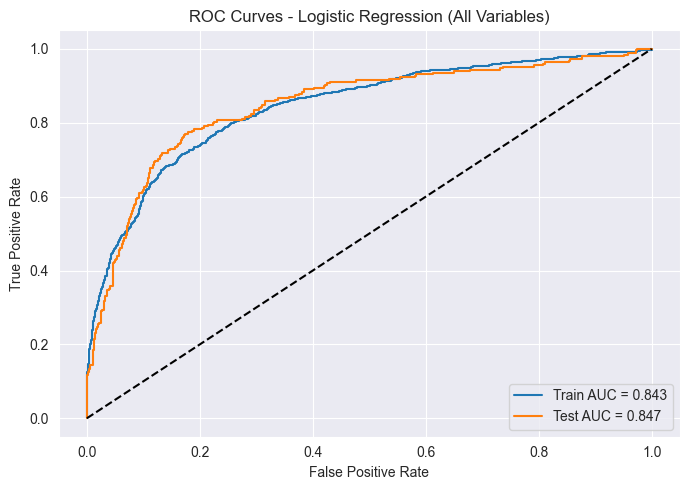


### Logistic Regression Coefficients ###
INTERCEPT = -0.12552427214215225
LOAN = -2.2493251218303673e-05
z_IMP_JOB_MISSING = -0.06797257575704962
z_IMP_JOB_Mgr = 0.01286006456746003
z_IMP_JOB_Office = -0.13745506628993956
z_IMP_JOB_Other = 0.014980213591580785
z_IMP_JOB_Sales = 0.03230691110596888
z_IMP_JOB_ProfExe = -0.021476777539425358
z_IMP_JOB_Self = 0.0412816401471084
z_IMP_REASON_MISSING = 9.283230911134163e-05
z_IMP_REASON_HomeImp = 0.02223601631975382
z_IMP_REASON_DebtCon = -0.14780443851984462
M_MORTDUE = 0.020528037600002942
IMP_MORTDUE = -5.269999592362283e-06
M_VALUE = 0.1509323923891047
IMP_VALUE = 3.4493967338640844e-06
M_YOJ = -0.05056160173328157
IMP_YOJ = -0.03275417870097715
M_DEROG = -0.11776142543692159
IMP_DEROG = 0.6007457486851093
M_DELINQ = -0.07459390785371267
IMP_DELINQ = 1.0435664614376245
M_CLAGE = 0.045483161286853174
IMP_CLAGE = -0.007468485537226857
M_NINQ = -0.04732721915713743
IMP_NINQ = 0.07783106919997737
M_CLNO = 0.028867784877946036
IMP_CLNO = -0.

In [75]:
### Logistic Regression Model - ALL VARIABLES

X = df.drop(columns=[TARGET_F, TARGET_A])
Y = df[TARGET_F]


X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=1
)
print("TRAINING SET:", X_train.shape)
print("TEST SET:", X_test.shape)
print("--------")


varNames = list( X.columns.values )
m = LogisticRegression(max_iter=1000)
m.fit(X,Y)

PRED_TRAIN_FLAG = m.predict(X_train)
PRED_TEST_FLAG  = m.predict(X_test)

PRED_TRAIN_PROB = m.predict_proba(X_train)[:, 1]
PRED_TEST_PROB  = m.predict_proba(X_test)[:, 1]

acc_train = metrics.accuracy_score(Y_train, PRED_TRAIN_FLAG)
acc_test  = metrics.accuracy_score(Y_test, PRED_TEST_FLAG)

print("Training Accuracy:", round(acc_train, 3))
print("Test Accuracy:", round(acc_test, 3))

fpr_train, tpr_train, _ = metrics.roc_curve(Y_train, PRED_TRAIN_PROB)
fpr_test, tpr_test, _   = metrics.roc_curve(Y_test, PRED_TEST_PROB)

auc_train = metrics.auc(fpr_train, tpr_train)
auc_test  = metrics.auc(fpr_test, tpr_test)

print("Training AUC:", round(auc_train, 3))
print("Test AUC:", round(auc_test, 3))



plt.figure(figsize=(7,5))
plt.plot(fpr_train, tpr_train, label=f"Train AUC = {auc_train:.3f}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {auc_test:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Logistic Regression (All Variables)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


print("\n### Logistic Regression Coefficients ###")
coef_dict = {"INTERCEPT": m.intercept_[0]}
for coef, feat in zip(m.coef_[0], X.columns):
    coef_dict[feat] = coef

for k, v in coef_dict.items():
    print(f"{k} = {v}")

print("\n--- Summary ---")
print(f"AUC (Test) = {auc_test:.3f} means the model correctly ranks defaults vs non-defaults {auc_test*100:.1f}% of the time.")
print(f"Accuracy (Test) = {acc_test:.3f} means the model correctly classified about {acc_test*100:.1f}% of loans.")
print("Positive coefficients indicate variables that INCREASE the probability of default while negative coefficients DECREASE it.")
print("If some coefficients seem unstable, possibly add scaling or regularization")


In [76]:
### Linear Regression Model - Decision Tree

df_defaulted = df[df["TARGET_BAD_FLAG"] == 1].copy()
df_defaulted = df_defaulted.dropna(subset=["TARGET_LOSS_AMT"])

X = df_defaulted.drop(columns=["TARGET_LOSS_AMT"])
Y = df_defaulted["TARGET_LOSS_AMT"]


def regResults( TITLE, X, Y, LIST ) :
    print( TITLE )
    W = X[ LIST ]
    N = W.shape[0]
    K = W.shape[1]
    print("Variables = ",K)
    print("")
    m = LinearRegression()
    m.fit( W, Y )
    R2 = m.score(W,Y)
    adjR2 = 1.0 - ((1.0-R2)*(N-1) / ( N - K - 1 ))
    adjR2 = round( 100.0 * adjR2, 1 )
    print( "Adjusted R2 = ", adjR2 )
    print("")
    COEF = m.coef_
    print("Intercept = ", m.intercept_ )
    for i in range( len(LIST) ) :
        print( LIST[i],"=",COEF[i] )



def getTreeVars( TREE, varNames ) :
    tree_ = TREE.tree_
    varName = [ varNames[i] if i != _tree.TREE_UNDEFINED else "undefined!" for i in tree_.feature ]
    nameSet = set()
    for i in tree_.feature :
        if i != _tree.TREE_UNDEFINED :
            nameSet.add( i )
    nameList = list( nameSet )
    parameter_list = list()
    for i in nameList :
        parameter_list.append( varNames[i] )
    return parameter_list

varNames = list(X.columns.values)

print("\n\n\n")
print("===========================")
print("TREE VARIABLES (selected on TRAIN)")
print("===========================")

theTree = tree.DecisionTreeRegressor(max_depth=4, random_state=1)
theTree = theTree.fit( X_train, Y_train )

treeList = getTreeVars( theTree, varNames )
print(treeList)

regResults( "TREE VARIABLES - TRAIN FIT", X_train, Y_train, treeList )


lin_model = LinearRegression().fit( X_train[treeList], Y_train )

pred_train = lin_model.predict( X_train[treeList] )
pred_test  = lin_model.predict( X_test[treeList] )

rmse_tree_train = np.sqrt( metrics.mean_squared_error(Y_train, pred_train) )
rmse_tree_test  = np.sqrt( metrics.mean_squared_error(Y_test,  pred_test) )

print("\n### RMSE (Decision Tree–Selected Variables)")
print("Train RMSE:", rmse_tree_train)
print("Test RMSE :", rmse_tree_test)







TREE VARIABLES (selected on TRAIN)
['IMP_MORTDUE', 'M_VALUE', 'M_YOJ', 'IMP_YOJ', 'M_DEROG', 'M_DELINQ', 'M_CLAGE', 'IMP_CLNO', 'M_DEBTINC']
TREE VARIABLES - TRAIN FIT
Variables =  9

Adjusted R2 =  33.5

Intercept =  0.13241014685579353
IMP_MORTDUE = -2.0810342828854327e-07
M_VALUE = 0.4882438092667097
M_YOJ = -0.06322527698129309
IMP_YOJ = -0.00298164636886464
M_DEROG = -0.08003235388516339
M_DELINQ = -0.027806290040360976
M_CLAGE = 0.08883681737906765
IMP_CLNO = 0.00020895294695778737
M_DEBTINC = 0.495061417014568

### RMSE (Decision Tree–Selected Variables)
Train RMSE: 0.3242333199950116
Test RMSE : 0.33057877793589807



TREE VARIABLES (selected on TRAIN)
['M_VALUE', 'IMP_VALUE', 'IMP_YOJ', 'M_DEROG', 'IMP_DEROG', 'IMP_DELINQ', 'IMP_CLAGE', 'M_DEBTINC', 'IMP_DEBTINC']


C:\Users\dchee\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
C:\Users\dchee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\optimize.py:100: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(


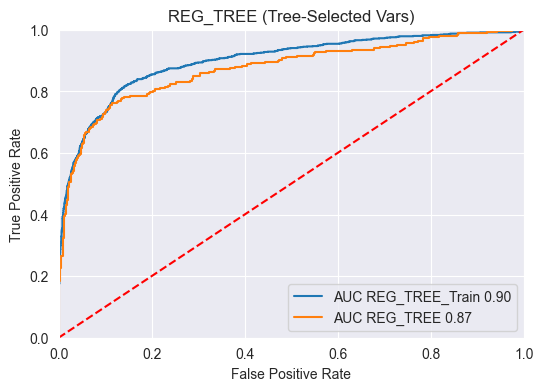

REG_TREE CLASSIFICATION ACCURACY
REG_TREE_Train  =  0.8865352348993288
REG_TREE  =  0.8800335570469798
------


### Logistic Regression Coefficients (Tree-Selected) ###
INTERCEPT  =  -5.219892444353853
M_VALUE  =  3.710694286257873
IMP_VALUE  =  2.6688060609885864e-07
IMP_YOJ  =  -0.016307325211653716
M_DEROG  =  -0.8181795866987851
IMP_DEROG  =  0.531056012428031
IMP_DELINQ  =  0.6787277065802719
IMP_CLAGE  =  -0.00582578876942373
M_DEBTINC  =  2.761273870156983
IMP_DEBTINC  =  0.0973469042436774


In [77]:
### Logistic Regression Model - Decision Tree

X = df.drop(columns=[TARGET_F, TARGET_A])
Y = df[TARGET_F]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=1
)

def getTreeVars(TREE, varNames):
    tree_ = TREE.tree_
    nameSet = set()
    for i in tree_.feature:
        if i != _tree.TREE_UNDEFINED:
            nameSet.add(i)
    nameList = list(nameSet)
    parameter_list = [varNames[i] for i in nameList]
    return parameter_list

def getProbAccuracyScores(NAME, MODEL, X, Y):
    pred  = MODEL.predict(X)
    probs = MODEL.predict_proba(X)
    acc   = metrics.accuracy_score(Y, pred)
    p1    = probs[:, 1]
    fpr, tpr, _ = metrics.roc_curve(Y, p1)
    auc   = metrics.auc(fpr, tpr)
    return [NAME, acc, fpr, tpr, auc]

def print_ROC_Curve(TITLE, LIST):
    plt.figure(figsize=(6,4))
    plt.title(TITLE)
    for res in LIST:
        NAME, _, fpr, tpr, auc = res
        label = "AUC " + NAME + f" {auc:0.2f}"
        plt.plot(fpr, tpr, label=label)
    plt.legend(loc='lower right')
    plt.plot([0,1],[0,1],'r--')
    plt.xlim([0,1]); plt.ylim([0,1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

def print_Accuracy(TITLE, LIST):
    print(TITLE)
    print("======")
    for res in LIST:
        NAME, ACC, *_ = res
        print(NAME, " = ", ACC)
    print("------\n")

varNames = list(X.columns.values)

print("\n===========================")
print("TREE VARIABLES (selected on TRAIN)")
print("===========================")
theTree = tree.DecisionTreeClassifier(max_depth=4, random_state=1)
theTree.fit(X_train, Y_train)

tree_vars = getTreeVars(theTree, varNames)
print(tree_vars)

WHO = "REG_TREE"
CLM = LogisticRegression(solver='newton-cg', max_iter=5000)
CLM.fit(X_train[tree_vars], Y_train)

TRAIN_CLM = getProbAccuracyScores(WHO + "_Train", CLM, X_train[tree_vars], Y_train)
TEST_CLM  = getProbAccuracyScores(WHO, CLM, X_test[tree_vars],  Y_test)

print_ROC_Curve(WHO + " (Tree-Selected Vars)", [TRAIN_CLM, TEST_CLM])
print_Accuracy(WHO + " CLASSIFICATION ACCURACY", [TRAIN_CLM, TEST_CLM])

coef_dict = {"INTERCEPT": CLM.intercept_[0]}
for c, f in zip(CLM.coef_[0], tree_vars):
    coef_dict[f] = c
print("\n### Logistic Regression Coefficients (Tree-Selected) ###")
for k, v in coef_dict.items():
    print(k, " = ", v)

RF-selected variables:
['M_VALUE', 'IMP_DEROG', 'IMP_DELINQ', 'IMP_CLAGE', 'M_DEBTINC', 'IMP_DEBTINC']
RF→Logit CLASSIFICATION ACCURACY
RF→Logit_Train = 0.882
RF→Logit_Test = 0.879
------



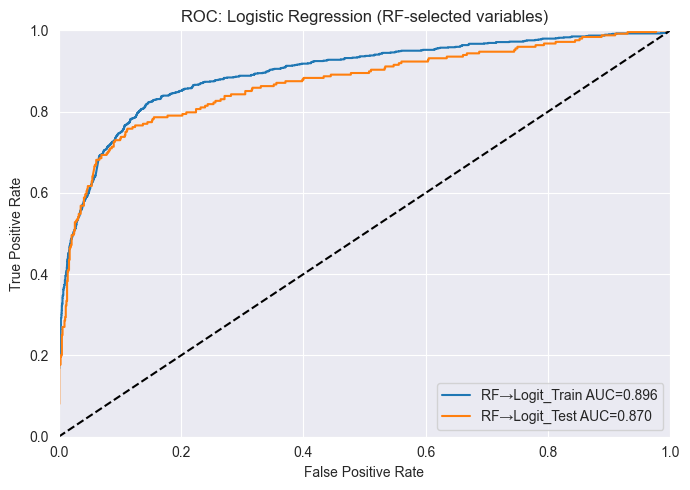


### Logistic Regression Coefficients (RF-selected) ###
INTERCEPT  =  -5.403729072829986
M_VALUE  =  3.5055649595365805
IMP_DEROG  =  0.5751696448500295
IMP_DELINQ  =  0.6501422021058246
IMP_CLAGE  =  -0.006192789793740587
M_DEBTINC  =  2.7565759848944844
IMP_DEBTINC  =  0.09891694565815579


In [78]:
### Logistic Regression Model - Random Forest

def getProbAccuracyScores(NAME, MODEL, X, Y):
    """Return [name, accuracy, fpr, tpr, auc] for a classifier on (X,Y)."""
    pred  = MODEL.predict(X)
    probs = MODEL.predict_proba(X)[:, 1]
    acc   = metrics.accuracy_score(Y, pred)
    fpr, tpr, _ = metrics.roc_curve(Y, probs)
    auc   = metrics.auc(fpr, tpr)
    return [NAME, acc, fpr, tpr, auc]

def print_ROC_Curve(TITLE, RESULTS):
    """Plot multiple ROC curves from a list of [name, acc, fpr, tpr, auc]."""
    plt.figure(figsize=(7,5))
    plt.title(TITLE)
    for name, _, fpr, tpr, auc in RESULTS:
        plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlim([0,1]); plt.ylim([0,1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

def print_Accuracy(TITLE, RESULTS):
    """Print accuracies for each result in RESULTS."""
    print(TITLE)
    print("======")
    for name, acc, *_ in RESULTS:
        print(f"{name} = {acc:.3f}")
    print("------\n")

X = df.drop(columns=[TARGET_F, TARGET_A])
Y = df[TARGET_F]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=1
)


rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    random_state=1,
    n_jobs=-1
)
rf.fit(X_train, Y_train)

importances = rf.feature_importances_
thr = np.mean(importances)

vars_RF_flag = [(X.columns[i], float(importances[i]))
                for i in range(len(importances)) if importances[i] > thr]
RF_flag = [name for name, _ in vars_RF_flag]

print("RF-selected variables:")
print(RF_flag)

if len(RF_flag) == 0:
    order = np.argsort(importances)[::-1]
    k = min(8, len(order))
    RF_flag = list(X.columns[order[:k]])
    print("\n[Note] No features > mean importance; using top-k by importance instead:")
    print(RF_flag)


CLM = LogisticRegression(solver='lbfgs', max_iter=5000)
CLM.fit(X_train[RF_flag], Y_train)

TRAIN_CLM_RF_LR = getProbAccuracyScores("RF→Logit_Train", CLM, X_train[RF_flag], Y_train)
TEST_CLM_RF_LR  = getProbAccuracyScores("RF→Logit_Test",  CLM, X_test[RF_flag],  Y_test)

print_Accuracy("RF→Logit CLASSIFICATION ACCURACY", [TRAIN_CLM_RF_LR, TEST_CLM_RF_LR])
print_ROC_Curve("ROC: Logistic Regression (RF-selected variables)",
                [TRAIN_CLM_RF_LR, TEST_CLM_RF_LR])

coef_dict = {"INTERCEPT": CLM.intercept_[0]}
for c, f in zip(CLM.coef_[0], RF_flag):
    coef_dict[f] = float(c)

print("\n### Logistic Regression Coefficients (RF-selected) ###")
for k, v in coef_dict.items():
    print(k, " = ", v)






In [79]:
### Linear Regression Model - Random Forest

X = df.drop(columns=[TARGET_F, TARGET_A])
Y = df[[TARGET_F, TARGET_A]]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=1
)

F_train = ~Y_train[TARGET_A].isna()
F_test  = ~Y_test[TARGET_A].isna()

W_train = X_train.loc[F_train].copy()
Z_train = Y_train.loc[F_train].copy()

W_test  = X_test.loc[F_test].copy()
Z_test  = Y_test.loc[F_test].copy()

print("REGRESSION DATA (Loss | Default):")
print("TRAIN rows:", W_train.shape[0], " TEST rows:", W_test.shape[0])
print("---------\n")

def getEnsembleTreeVars(ENSTREE, varNames):
    importance = ENSTREE.feature_importances_
    idx_sorted = np.argsort(importance)
    theList = []
    for i in idx_sorted:
        imp_val = importance[i]
        if imp_val > np.average(importance):
            v = int(imp_val / np.max(importance) * 100)
            theList.append((varNames[i], v))
    theList = sorted(theList, key=itemgetter(1), reverse=True)
    return theList

rf_amt = RandomForestRegressor(n_estimators=100, random_state=1)
rf_amt.fit(W_train, Z_train[TARGET_A])

feature_cols = list(X.columns.values)
vars_RF_amt = getEnsembleTreeVars(rf_amt, feature_cols)  # list of (name, scaled_importance)
RF_amt = [name for name, _ in vars_RF_amt]

if len(RF_amt) == 0:
    importances = rf_amt.feature_importances_
    order = np.argsort(importances)[::-1]
    k = min(8, len(order))
    RF_amt = [feature_cols[i] for i in order[:k]]

print("RF-selected variables for LOSS model:")
print(RF_amt)

lm = LinearRegression()
lm.fit(W_train[RF_amt], Z_train[TARGET_A])

pred_train = lm.predict(W_train[RF_amt])
pred_test  = lm.predict(W_test[RF_amt])

rmse_rf_train = np.sqrt(metrics.mean_squared_error(Z_train[TARGET_A], pred_train))
rmse_rf_test  = np.sqrt(metrics.mean_squared_error(Z_test[TARGET_A],  pred_test))

print("\n### REG_RF (Linear on RF-selected vars) — RMSE")
print("Train RMSE:", rmse_rf_train)
print("Test RMSE :", rmse_rf_test)

print("\n### Linear Regression Coefficients (RF-selected) ###")
print("INTERCEPT =", lm.intercept_)
for coef, feat in zip(lm.coef_, RF_amt):
    print(feat, "=", coef)


REGRESSION DATA (Loss | Default):
TRAIN rows: 941  TEST rows: 248
---------

RF-selected variables for LOSS model:
['LOAN', 'IMP_CLNO', 'IMP_DEBTINC']

### REG_RF (Linear on RF-selected vars) — RMSE
Train RMSE: 5128.0038815240705
Test RMSE : 5381.0104159517505

### Linear Regression Coefficients (RF-selected) ###
INTERCEPT = -6566.743371416629
LOAN = 0.7272984265393585
IMP_CLNO = 255.45668969639553
IMP_DEBTINC = 62.78970516702114


Gradient Boosting–selected variables for FLAG model:
['M_DEBTINC', 'IMP_DEBTINC', 'IMP_DELINQ', 'IMP_CLAGE', 'IMP_DEROG']
GB→Logit CLASSIFICATION ACCURACY
GB→Logit_Train = 0.877
GB→Logit_Test = 0.870
------



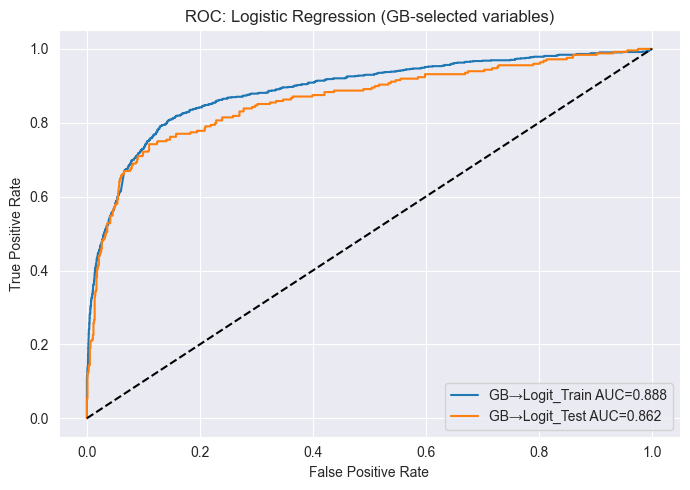


### Logistic Regression Coefficients (GB-selected) ###
INTERCEPT  =  -5.17478973666265
M_DEBTINC  =  2.7866469199186277
IMP_DEBTINC  =  0.09387314196926662
IMP_DELINQ  =  0.6677891252697613
IMP_CLAGE  =  -0.006211691344575429
IMP_DEROG  =  0.5741377886357125


In [80]:
### Logistic Regression Model - Gradient Boosting

X = df.drop(columns=[TARGET_F, TARGET_A])
Y = df[TARGET_F]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.8, random_state=1
)


gb = GradientBoostingClassifier(random_state=1)
gb.fit(X_train, Y_train)

def getEnsembleTreeVars(ENSTREE, varNames):
    importance = ENSTREE.feature_importances_
    index = np.argsort(importance)
    theList = []
    for i in index:
        imp_val = importance[i]
        if imp_val > np.average(importance):
            v = int(imp_val / np.max(importance) * 100)
            theList.append((varNames[i], v))
    theList = sorted(theList, key=lambda x: x[1], reverse=True)
    return theList

feature_cols = list(X.columns.values)
vars_GB_flag = getEnsembleTreeVars(gb, feature_cols)
GB_flag = [i[0] for i in vars_GB_flag]

if len(GB_flag) == 0:
    importances = gb.feature_importances_
    order = np.argsort(importances)[::-1]
    k = min(8, len(order))
    GB_flag = [feature_cols[i] for i in order[:k]]
    print("\n[Note] No features > mean importance; using top-k by importance instead:")
print("Gradient Boosting–selected variables for FLAG model:")
print(GB_flag)


CLM = LogisticRegression(solver='newton-cg', max_iter=1000)
CLM.fit(X_train[GB_flag], Y_train)


def getProbAccuracyScores(NAME, MODEL, X, Y):
    pred = MODEL.predict(X)
    probs = MODEL.predict_proba(X)[:, 1]
    acc = metrics.accuracy_score(Y, pred)
    fpr, tpr, _ = metrics.roc_curve(Y, probs)
    auc = metrics.auc(fpr, tpr)
    return [NAME, acc, fpr, tpr, auc]

def print_ROC_Curve(TITLE, RESULTS):
    plt.figure(figsize=(7,5))
    plt.title(TITLE)
    for name, _, fpr, tpr, auc in RESULTS:
        plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

def print_Accuracy(TITLE, RESULTS):
    print(TITLE)
    print("======")
    for name, acc, *_ in RESULTS:
        print(f"{name} = {acc:.3f}")
    print("------\n")

TRAIN_CLM_GB_LR = getProbAccuracyScores("GB→Logit_Train", CLM, X_train[GB_flag], Y_train)
TEST_CLM_GB_LR  = getProbAccuracyScores("GB→Logit_Test",  CLM, X_test[GB_flag],  Y_test)

print_Accuracy("GB→Logit CLASSIFICATION ACCURACY", [TRAIN_CLM_GB_LR, TEST_CLM_GB_LR])
print_ROC_Curve("ROC: Logistic Regression (GB-selected variables)",
                [TRAIN_CLM_GB_LR, TEST_CLM_GB_LR])


coef_dict = {"INTERCEPT": CLM.intercept_[0]}
for c, f in zip(CLM.coef_[0], GB_flag):
    coef_dict[f] = float(c)

print("\n### Logistic Regression Coefficients (GB-selected) ###")
for k, v in coef_dict.items():
    print(k, " = ", v)



In [81]:
### Linear Regression Model - Gradient Boosting
X = df.drop(columns=[TARGET_F, TARGET_A])
Y = df[[TARGET_F, TARGET_A]]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=1
)

# Keep only loans that defaulted (non-null loss)
F_train = ~Y_train[TARGET_A].isna()
F_test  = ~Y_test[TARGET_A].isna()

W_train = X_train.loc[F_train].copy()
Z_train = Y_train.loc[F_train].copy()
W_test  = X_test.loc[F_test].copy()
Z_test  = Y_test.loc[F_test].copy()

print("REGRESSION DATA (Loss | Default):")
print("TRAIN rows:", W_train.shape[0], " TEST rows:", W_test.shape[0])
print("---------\n")


gb_reg = GradientBoostingRegressor(random_state=1)
gb_reg.fit(W_train, Z_train[TARGET_A])

def getEnsembleTreeVars(ENSTREE, varNames):
    importance = ENSTREE.feature_importances_
    index = np.argsort(importance)
    selected = []
    for i in index:
        imp = importance[i]
        if imp > np.average(importance):
            pct = int(imp / np.max(importance) * 100)
            selected.append((varNames[i], pct))
    selected = sorted(selected, key=lambda x: x[1], reverse=True)
    return selected

varNames = list(W_train.columns.values)
vars_GB_amt = getEnsembleTreeVars(gb_reg, varNames)
GB_amt = [i[0] for i in vars_GB_amt]

# Safety check: if no vars above mean, pick top 10
if len(GB_amt) == 0:
    importances = gb_reg.feature_importances_
    order = np.argsort(importances)[::-1]
    GB_amt = [varNames[i] for i in order[:10]]

print("Gradient Boosting–selected variables for LOSS model:")
print(GB_amt)


lm_gb = LinearRegression()
lm_gb.fit(W_train[GB_amt], Z_train[TARGET_A])

pred_train = lm_gb.predict(W_train[GB_amt])
pred_test  = lm_gb.predict(W_test[GB_amt])

rmse_gb_train = np.sqrt(metrics.mean_squared_error(Z_train[TARGET_A], pred_train))
rmse_gb_test  = np.sqrt(metrics.mean_squared_error(Z_test[TARGET_A],  pred_test))

print("\n### REG_GB (Linear Regression using GB-selected variables)")
print("Train RMSE:", rmse_gb_train)
print("Test RMSE :", rmse_gb_test)

print("\n### Linear Regression Coefficients (GB-selected variables) ###")
print("INTERCEPT =", lm_gb.intercept_)
for feat, coef in zip(GB_amt, lm_gb.coef_):
    print(f"{feat} = {coef:.4f}")

REGRESSION DATA (Loss | Default):
TRAIN rows: 941  TEST rows: 248
---------

Gradient Boosting–selected variables for LOSS model:
['LOAN', 'IMP_CLNO', 'IMP_DEBTINC', 'M_DEBTINC']

### REG_GB (Linear Regression using GB-selected variables)
Train RMSE: 4408.564694728578
Test RMSE : 4465.163660738357

### Linear Regression Coefficients (GB-selected variables) ###
INTERCEPT = -12580.151025484232
LOAN = 0.7492
IMP_CLNO = 246.2872
IMP_DEBTINC = 117.6680
M_DEBTINC = 5736.3010


LOGISTIC REGRESSION (Stepwise Variables)
Train rows: 4768  Test rows: 1192
---------

Stepwise-selected variables for Logistic Regression:
['z_IMP_JOB_MISSING', 'z_IMP_JOB_Mgr', 'z_IMP_JOB_ProfExe', 'z_IMP_JOB_Self', 'z_IMP_REASON_MISSING', 'IMP_MORTDUE', 'M_VALUE', 'IMP_YOJ', 'M_DEROG', 'IMP_DEROG', 'M_DELINQ', 'IMP_DELINQ', 'M_CLAGE', 'IMP_CLAGE', 'IMP_NINQ', 'M_CLNO', 'M_DEBTINC', 'IMP_DEBTINC']
STEPWISE Logistic CLASSIFICATION ACCURACY
STEP→Logit_Train = 0.897
STEP→Logit_Test = 0.889
------



C:\Users\dchee\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
C:\Users\dchee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\optimize.py:100: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(


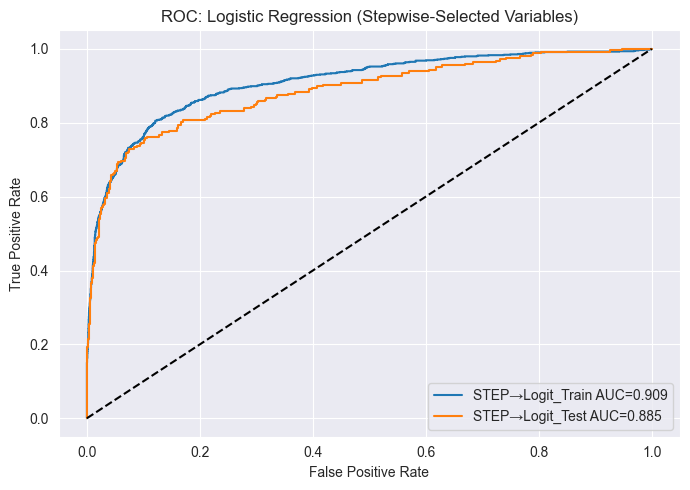


### Logistic Regression Coefficients (Stepwise Selected) ###
INTERCEPT = -5.3062
z_IMP_JOB_MISSING = -1.5407
z_IMP_JOB_Mgr = 0.0417
z_IMP_JOB_ProfExe = -0.1391
z_IMP_JOB_Self = 0.2893
z_IMP_REASON_MISSING = -0.1613
IMP_MORTDUE = -0.0000
M_VALUE = 3.8288
IMP_YOJ = -0.0139
M_DEROG = -1.7019
IMP_DEROG = 0.5126
M_DELINQ = -0.3895
IMP_DELINQ = 0.7413
M_CLAGE = 1.2509
IMP_CLAGE = -0.0058
IMP_NINQ = 0.1269
M_CLNO = 1.9829
M_DEBTINC = 2.6835
IMP_DEBTINC = 0.0969


In [82]:
### Logistic Regression Model - Stepwise Selection

X = df.drop(columns=[TARGET_F, TARGET_A])
Y = df[TARGET_F]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=1
)

print("LOGISTIC REGRESSION (Stepwise Variables)")
print("Train rows:", X_train.shape[0], " Test rows:", X_test.shape[0])
print("---------\n")

# --------------------------------------------------------------
# 3. Stepwise Feature Selection (Forward + Floating)
# --------------------------------------------------------------
logit = LogisticRegression(solver='newton-cg', max_iter=1000)

sfs = SFS(
    logit,
    k_features="best",
    forward=True,
    floating=True,
    scoring="accuracy",
    cv=4,
    n_jobs=-1
)
sfs.fit(X_train, Y_train)

# Build summary DataFrame
dfm = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
dfm = dfm[["feature_names", "avg_score"]]
dfm["avg_score"] = dfm["avg_score"].astype(float)
dfm.sort_values(by="avg_score", ascending=False, inplace=True)

# Best subset
best_idx = dfm["avg_score"].idxmax()
best_vars = list(dfm.loc[best_idx, "feature_names"])
print("Stepwise-selected variables for Logistic Regression:")
print(best_vars)

# --------------------------------------------------------------
# 4. Fit Logistic Regression with Stepwise Variables
# --------------------------------------------------------------
CLM = LogisticRegression(solver='newton-cg', max_iter=1000)
CLM.fit(X_train[best_vars], Y_train)

# --------------------------------------------------------------
# 5. Evaluate Accuracy and AUC (Train/Test)
# --------------------------------------------------------------
def getProbAccuracyScores(NAME, MODEL, X, Y):
    pred = MODEL.predict(X)
    probs = MODEL.predict_proba(X)[:, 1]
    acc = metrics.accuracy_score(Y, pred)
    fpr, tpr, _ = metrics.roc_curve(Y, probs)
    auc = metrics.auc(fpr, tpr)
    return [NAME, acc, fpr, tpr, auc]

def print_ROC_Curve(TITLE, RESULTS):
    plt.figure(figsize=(7,5))
    plt.title(TITLE)
    for name, _, fpr, tpr, auc in RESULTS:
        plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

def print_Accuracy(TITLE, RESULTS):
    print(TITLE)
    print("======")
    for name, acc, *_ in RESULTS:
        print(f"{name} = {acc:.3f}")
    print("------\n")

TRAIN_STEP_LR = getProbAccuracyScores("STEP→Logit_Train", CLM, X_train[best_vars], Y_train)
TEST_STEP_LR  = getProbAccuracyScores("STEP→Logit_Test",  CLM, X_test[best_vars],  Y_test)

print_Accuracy("STEPWISE Logistic CLASSIFICATION ACCURACY", [TRAIN_STEP_LR, TEST_STEP_LR])
print_ROC_Curve("ROC: Logistic Regression (Stepwise-Selected Variables)",
                [TRAIN_STEP_LR, TEST_STEP_LR])

# --------------------------------------------------------------
# 6. Coefficients
# --------------------------------------------------------------
coef_dict = {"INTERCEPT": CLM.intercept_[0]}
for c, f in zip(CLM.coef_[0], best_vars):
    coef_dict[f] = float(c)

print("\n### Logistic Regression Coefficients (Stepwise Selected) ###")
for k, v in coef_dict.items():
    print(f"{k} = {v:.4f}")

REGRESSION DATA (Loss | Default):
TRAIN rows: 941  TEST rows: 248
---------

Stepwise-selected variables:
['LOAN', 'z_IMP_JOB_ProfExe', 'z_IMP_JOB_Self', 'z_IMP_REASON_DebtCon', 'IMP_YOJ', 'IMP_DEROG', 'M_DELINQ', 'IMP_DELINQ', 'M_CLAGE', 'IMP_CLAGE', 'M_CLNO', 'IMP_CLNO', 'M_DEBTINC', 'IMP_DEBTINC']

### REG_STEPWISE (Linear Regression on Stepwise-Selected Vars)
Train RMSE: 3643.010745234009
Test RMSE : 3589.4948708452216

### Linear Regression Coefficients (Stepwise Selected) ###
INTERCEPT = -10452.2982
LOAN = 0.7538
z_IMP_JOB_ProfExe = -435.9445
z_IMP_JOB_Self = 1317.8130
z_IMP_REASON_DebtCon = 2054.0704
IMP_YOJ = -89.3932
IMP_DEROG = 285.9761
M_DELINQ = 724.4640
IMP_DELINQ = 730.2167
M_CLAGE = -5391.8085
IMP_CLAGE = -18.4968
M_CLNO = 6672.2461
IMP_CLNO = 214.9453
M_DEBTINC = 5591.7048
IMP_DEBTINC = 110.6334


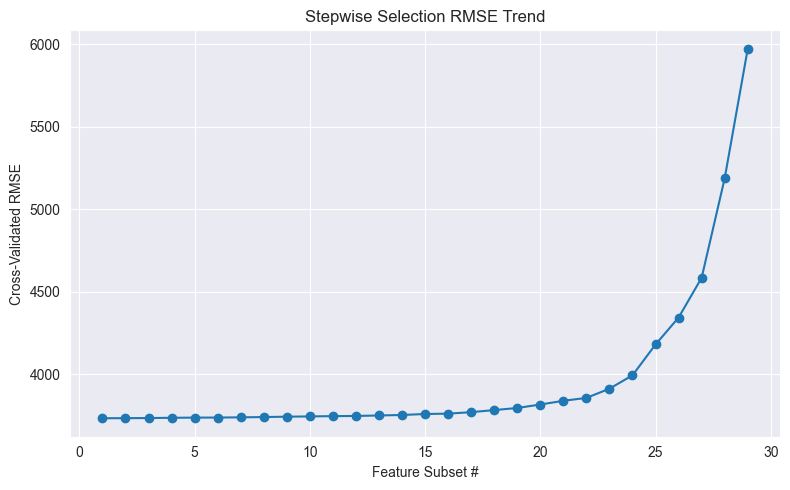

In [83]:
### Linear Regression Model - Stepwise Selection

X = df.drop(columns=[TARGET_F, TARGET_A])
Y = df[[TARGET_F, TARGET_A]]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=1
)

F_train = ~Y_train[TARGET_A].isna()
F_test  = ~Y_test[TARGET_A].isna()

W_train = X_train.loc[F_train].copy()
Z_train = Y_train.loc[F_train].copy()
W_test  = X_test.loc[F_test].copy()
Z_test  = Y_test.loc[F_test].copy()

print("REGRESSION DATA (Loss | Default):")
print("TRAIN rows:", W_train.shape[0], " TEST rows:", W_test.shape[0])
print("---------\n")


lm = LinearRegression()

sfs = SFS(
    lm,
    k_features="best",
    forward=True,
    floating=True,
    scoring="neg_root_mean_squared_error",
    cv=4,
    n_jobs=-1
)
sfs.fit(W_train, Z_train[TARGET_A])

dfm = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
dfm = dfm[["feature_names", "avg_score"]]
dfm["avg_score"] = dfm["avg_score"].astype(float)
dfm.sort_values(by="avg_score", ascending=False, inplace=True)

best_idx = dfm["avg_score"].idxmax()
best_vars = list(dfm.loc[best_idx, "feature_names"])
print("Stepwise-selected variables:")
print(best_vars)


lm_best = LinearRegression()
lm_best.fit(W_train[best_vars], Z_train[TARGET_A])

pred_train = lm_best.predict(W_train[best_vars])
pred_test  = lm_best.predict(W_test[best_vars])

rmse_step_train = np.sqrt(metrics.mean_squared_error(Z_train[TARGET_A], pred_train))
rmse_step_test  = np.sqrt(metrics.mean_squared_error(Z_test[TARGET_A],  pred_test))

print("\n### REG_STEPWISE (Linear Regression on Stepwise-Selected Vars)")
print("Train RMSE:", rmse_step_train)
print("Test RMSE :", rmse_step_test)


coef_dict = {"INTERCEPT": float(lm_best.intercept_)}
for c, f in zip(lm_best.coef_, best_vars):
    coef_dict[f] = float(c)

print("\n### Linear Regression Coefficients (Stepwise Selected) ###")
for k, v in coef_dict.items():
    print(f"{k} = {v:.4f}")


plt.figure(figsize=(8,5))
plt.plot(range(1, len(dfm)+1), -dfm["avg_score"], marker="o")
plt.xlabel("Feature Subset #")
plt.ylabel("Cross-Validated RMSE")
plt.title("Stepwise Selection RMSE Trend")
plt.grid(True)
plt.tight_layout()
plt.show()


In [84]:
summary = pd.DataFrame([
    ["Linear – All Variables",       rmse_all_train,   rmse_all_test],
    ["Linear – Tree Vars",           rmse_tree_train,  rmse_tree_test],
    ["Linear – RF Vars",             rmse_rf_train,    rmse_rf_test],
    ["Linear – GB Vars",             rmse_gb_train,    rmse_gb_test],
    ["Linear – Stepwise Vars",       rmse_step_train,  rmse_step_test],
], columns=["Model", "Train_RMSE", "Test_RMSE"])

summary


,Model,Train_RMSE,Test_RMSE
0,Linear – All Variables,3613.472655,3493.138390
1,Linear – Tree Vars,0.324233,0.330579
2,Linear – RF Vars,5128.003882,5381.010416
3,Linear – GB Vars,4408.564695,4465.163661
4,Linear – Stepwise Vars,3643.010745,3589.494871
